# Topological Shell-Disk Limit Evaluation

This notebook evaluates whether the DDPM deconvolution / super-resolution model preserves a shell topology in the small-cavity limit instead of degenerating the prediction into a filled disk.

It implements configurable SD dataset/model loading, DDPM batch inference over 300 LR images, centroided azimuthal radial profiles, cavity contrast `C = 1 - I_center / I_peak`, topological fidelity curves over `k = R_in / R_out`, and representative success/failure visualizations.


In [1]:
from pathlib import Path
import csv
import importlib
import json
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "codes").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing codes/ and data/.")


ADDR_ROOT = find_repo_root()
ADDR_CODE = ADDR_ROOT / "codes"
ADDR_MODELS = ADDR_CODE / "models"
for path in [ADDR_ROOT, ADDR_CODE, ADDR_MODELS]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.append(path_str)

from codes.config.config_DDPM import ModelConfig

print(f"ADDR_ROOT = {ADDR_ROOT}")
print(f"CUDA available = {torch.cuda.is_available()}")


ADDR_ROOT = /root/LHAI_novel
CUDA available = True


/root/miniconda3/envs/LHAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup and data loading

Change `MAP_KIND`, `IMAGE_SIZE`, and optionally `MODEL_WEIGHT_NAME` before running the notebook. If `MODEL_WEIGHT_NAME` is `None`, the notebook uses the six-model naming convention under `saves/MODEL/DDPM`.


In [2]:
MAP_KIND = "poisonon"  # one of: excess, bkgon, poisonon
IMAGE_SIZE = 64       # 64 or 128
DATA_RANGE = 2.0

MODEL_WEIGHT_NAME = "Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.pth"
DIFFUSION_MODULE_NAME = "DDPM"
DIFFUSION_CLASS_NAME = "DDPM"
UNET_MODULE_NAME = "UNET"
UNET_CLASS_NAME = "UNET"
UNET_CONFIG_KEY = "UNET"
DIFFUSION_CONFIG_KEY = "DDPM_64"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
STRICT_LOAD = True
CLAMP_OUTPUT = False
OVERRIDE_IMG_SIZE_FROM_DATA = True
INFERENCE_BATCH_SIZE = 50
SAMPLING_SEED = 2026
USE_CACHED_DDPM_OUTPUTS = False
SAVE_OUTPUTS = True

R_OUTS = np.array([0.5, 0.75, 1.0], dtype=float)
K_RATIOS = np.linspace(0.1, 1.0, 100)
CAVITY_THRESHOLD = 0.15
METRIC_MINMAX_NORMALIZE = True

REPRESENTATIVE_INDEX = None
SHOW_AUTOMATIC_SUCCESS_CASE = True
SHOW_FAILURE_CASE = True
FAILURE_CASE_COUNT = 10

DATA_DIR_CANDIDATES = [
    ADDR_ROOT / "data" / "Evaluation" / "Physical_Limits",
    ADDR_ROOT / "data" / "Evaluation",
]
MODEL_WEIGHT_DIR = ADDR_ROOT / "saves" / "MODEL" / "DDPM"
OUTPUT_DIR = ADDR_ROOT / "saves" / "EVAL" / "DDPM" / "TopologicalLimit"

DATA_NAME = f"SD{MAP_KIND}_300_{IMAGE_SIZE}_test.npy"
print(f"DATA_NAME = {DATA_NAME}")
print(f"DIFFUSION_CONFIG_KEY = {DIFFUSION_CONFIG_KEY}")


DATA_NAME = SDpoisonon_300_64_test.npy
DIFFUSION_CONFIG_KEY = DDPM_64


In [3]:
VALID_MAP_KINDS = {"excess", "bkgon", "poisonon"}
VALID_IMAGE_SIZES = {64, 128}
EXPECTED_N_IMAGES = len(R_OUTS) * len(K_RATIOS)


def resolve_existing_data_path(data_name):
    checked = []
    for data_dir in DATA_DIR_CANDIDATES:
        candidate = data_dir / data_name
        checked.append(candidate)
        if candidate.exists():
            return candidate
    checked_text = "\n".join(f"  {path}" for path in checked)
    raise FileNotFoundError(f"Could not find {data_name}. Checked:\n{checked_text}")


def default_weight_name(map_kind, image_size):
    return f"Last_DDPM_EXP01_400epo_32bth_{image_size}size_SR4{map_kind}.pth"


def resolve_model_weight_path(weight_name):
    if weight_name is not None:
        candidate = MODEL_WEIGHT_DIR / weight_name
        if not candidate.exists():
            raise FileNotFoundError(candidate)
        return weight_name, candidate

    exact_name = default_weight_name(MAP_KIND, IMAGE_SIZE)
    exact_path = MODEL_WEIGHT_DIR / exact_name
    if exact_path.exists():
        return exact_name, exact_path

    candidates = sorted(MODEL_WEIGHT_DIR.glob(f"*{IMAGE_SIZE}size*{MAP_KIND}*.pth"))
    if len(candidates) == 1:
        return candidates[0].name, candidates[0]

    available = sorted(path.name for path in MODEL_WEIGHT_DIR.glob("*.pth")) if MODEL_WEIGHT_DIR.exists() else []
    available_text = "\n".join(f"  {name}" for name in available)
    raise FileNotFoundError(
        f"Could not infer a unique DDPM weight for MAP_KIND={MAP_KIND!r}, IMAGE_SIZE={IMAGE_SIZE}.\n"
        f"Expected default: {exact_name}\nAvailable weights:\n{available_text}"
    )


if MAP_KIND not in VALID_MAP_KINDS:
    raise ValueError(f"MAP_KIND must be one of {sorted(VALID_MAP_KINDS)}, got {MAP_KIND!r}")
if IMAGE_SIZE not in VALID_IMAGE_SIZES:
    raise ValueError(f"IMAGE_SIZE must be one of {sorted(VALID_IMAGE_SIZES)}, got {IMAGE_SIZE!r}")

DATA_NAME = f"SD{MAP_KIND}_300_{IMAGE_SIZE}_test.npy"
data_path = resolve_existing_data_path(DATA_NAME)
MODEL_WEIGHT_NAME, model_weight_path = resolve_model_weight_path(MODEL_WEIGHT_NAME)
RUN_STEM = f"{Path(DATA_NAME).stem}__{Path(MODEL_WEIGHT_NAME).stem}"

raw_data = np.load(data_path, allow_pickle=True)
if raw_data.shape[:2] != (EXPECTED_N_IMAGES, 2):
    raise ValueError(f"Expected first dimensions ({EXPECTED_N_IMAGES}, 2), got {raw_data.shape}")

gt_raw = np.asarray(raw_data[:, 0], dtype=np.float32)
lr_raw = np.asarray(raw_data[:, 1], dtype=np.float32)
expected_image_shape = (EXPECTED_N_IMAGES, IMAGE_SIZE, IMAGE_SIZE)
if gt_raw.shape != expected_image_shape or lr_raw.shape != expected_image_shape:
    raise ValueError(f"Expected GT/LR shape {expected_image_shape}, got GT={gt_raw.shape}, LR={lr_raw.shape}")

print(f"Loaded data: {data_path}")
print(f"Loaded weight: {model_weight_path}")
print(f"GT shape={gt_raw.shape}, range=({gt_raw.min():.4g}, {gt_raw.max():.4g})")
print(f"LR shape={lr_raw.shape}, range=({lr_raw.min():.4g}, {lr_raw.max():.4g})")
print(f"Parameter grid: {len(R_OUTS)} R_out values x {len(K_RATIOS)} k values = {EXPECTED_N_IMAGES} samples")


Loaded data: /root/LHAI_novel/data/Evaluation/SDpoisonon_300_64_test.npy
Loaded weight: /root/LHAI_novel/saves/MODEL/DDPM/Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.pth
GT shape=(300, 64, 64), range=(0, 1.032e+04)
LR shape=(300, 64, 64), range=(0, 4697)
Parameter grid: 3 R_out values x 100 k values = 300 samples


## 2. DDPM model loading and batch inference

The LR input is normalized sample-by-sample into the same numeric range used by the existing DDPM evaluation notebook. The topology metric later re-normalizes each image to `[0, 1]` by default, so cavity contrast is measured as a shape contrast rather than an absolute flux scale.


In [4]:
def minmax_normalize_batch(images, data_range=1.0):
    images = np.asarray(images, dtype=np.float32)
    flat = images.reshape(images.shape[0], -1)
    mins = flat.min(axis=1).reshape((-1, 1, 1))
    maxs = flat.max(axis=1).reshape((-1, 1, 1))
    norm01 = (images - mins) / np.maximum(maxs - mins, 1e-8)
    if abs(data_range - 1.0) < 1e-6:
        return norm01.astype(np.float32)
    if abs(data_range - 2.0) < 1e-6:
        return (2.0 * norm01 - 1.0).astype(np.float32)
    raise ValueError("DATA_RANGE must be 1.0 or 2.0")


def import_model_class(module_name, class_name):
    try:
        module = importlib.import_module(f"codes.models.{module_name}")
    except ModuleNotFoundError:
        module = importlib.import_module(module_name)
    return getattr(module, class_name)


lr_model_np = minmax_normalize_batch(lr_raw, DATA_RANGE)
gt_model_np = minmax_normalize_batch(gt_raw, DATA_RANGE)

model_cfg = ModelConfig()
model_params = model_cfg.model_params
params_diffusion = dict(model_params[DIFFUSION_CONFIG_KEY])
params_unet = dict(model_params[UNET_CONFIG_KEY])
if OVERRIDE_IMG_SIZE_FROM_DATA:
    params_diffusion["img_size"] = IMAGE_SIZE
params_diffusion["device"] = torch.device(DEVICE)

device = torch.device(DEVICE)
DIFFUSION = import_model_class(DIFFUSION_MODULE_NAME, DIFFUSION_CLASS_NAME)
UNET = import_model_class(UNET_MODULE_NAME, UNET_CLASS_NAME)

diffusion = DIFFUSION(**params_diffusion)
unet = UNET(**params_unet).to(device)
if hasattr(unet, "build"):
    unet.build()
unet.to(device)

state = torch.load(model_weight_path, map_location=device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
try:
    unet.load_state_dict(state, strict=STRICT_LOAD)
except RuntimeError:
    if isinstance(state, dict) and any(key.startswith("module.") for key in state):
        stripped_state = {key.removeprefix("module."): value for key, value in state.items()}
        unet.load_state_dict(stripped_state, strict=STRICT_LOAD)
    else:
        raise
unet.eval()

print(f"Loaded model: {DIFFUSION_CONFIG_KEY} + {UNET_CONFIG_KEY} on {device}")


Loaded model: DDPM_64 + UNET on cuda


In [5]:
def reduce_generated(generated, batch_size):
    if generated.dim() == 5:
        if generated.shape[0] == batch_size:
            generated = generated[:, -1]
        else:
            generated = generated[-1]
    if generated.dim() != 4:
        raise ValueError(f"Expected generated tensor with 4 dimensions, got {tuple(generated.shape)}")
    if CLAMP_OUTPUT:
        generated = generated.clamp(-1.0, 1.0) if DATA_RANGE == 2.0 else generated.clamp(0.0, 1.0)
    return generated


@torch.no_grad()
def generate_ddpm_outputs(lr_batch_np):
    outputs = []
    for start in tqdm(range(0, len(lr_batch_np), INFERENCE_BATCH_SIZE), desc="DDPM topology inference"):
        batch = lr_batch_np[start:start + INFERENCE_BATCH_SIZE]
        batch_tensor = torch.from_numpy(batch[:, None]).float().to(device)
        torch.manual_seed(SAMPLING_SEED + start)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SAMPLING_SEED + start)
        generated = diffusion.reverse_diffusion(
            model=unet,
            n_images=batch_tensor.shape[0],
            n_channels=1,
            input_image=batch_tensor,
            save_time_steps=None,
        )
        generated = reduce_generated(generated, batch_tensor.shape[0]).detach().cpu().numpy()[:, 0]
        outputs.append(generated.astype(np.float32))
        del batch_tensor, generated
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return np.concatenate(outputs, axis=0)


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ddpm_cache_path = OUTPUT_DIR / f"ddpm_outputs__{RUN_STEM}.npy"
if USE_CACHED_DDPM_OUTPUTS and ddpm_cache_path.exists():
    ddpm_np = np.load(ddpm_cache_path).astype(np.float32)
    print(f"Loaded cached DDPM outputs: {ddpm_cache_path}")
else:
    ddpm_np = generate_ddpm_outputs(lr_model_np)
    if SAVE_OUTPUTS:
        np.save(ddpm_cache_path, ddpm_np.astype(np.float32))
        print(f"Saved DDPM outputs: {ddpm_cache_path}")

if ddpm_np.shape != (EXPECTED_N_IMAGES, IMAGE_SIZE, IMAGE_SIZE):
    raise ValueError(f"Expected DDPM output shape {(EXPECTED_N_IMAGES, IMAGE_SIZE, IMAGE_SIZE)}, got {ddpm_np.shape}")
print(f"DDPM output shape={ddpm_np.shape}, range=({ddpm_np.min():.4g}, {ddpm_np.max():.4g})")


DDPM topology inference: 100%|██████████| 6/6 [00:31<00:00,  5.25s/it]

Saved DDPM outputs: /root/LHAI_novel/saves/EVAL/DDPM/TopologicalLimit/ddpm_outputs__SDpoisonon_300_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.npy
DDPM output shape=(300, 64, 64), range=(-1.072, 1.662)


## 3. Cavity contrast calculation

For each image, the metric is computed from a centroided azimuthal average: estimate the photometric centroid from non-negative image intensity, bin pixels by distance to the centroid, use `I_center = I_rad(0)` and `I_peak = max(I_rad)`, then define `C = max(0, 1 - I_center / I_peak)`. The shell is resolved when `C > 0.15`.


In [6]:
def prepare_metric_image(image, normalize=METRIC_MINMAX_NORMALIZE):
    arr = np.asarray(image, dtype=np.float64).squeeze()
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D image after squeeze, got shape {arr.shape}")
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    if normalize:
        min_val = float(arr.min())
        max_val = float(arr.max())
        if max_val > min_val:
            arr = (arr - min_val) / (max_val - min_val)
        else:
            arr = np.zeros_like(arr)
    return arr


def calculate_centroid(image):
    arr = prepare_metric_image(image)
    weights = np.clip(arr, 0.0, None)
    total = float(weights.sum())
    height, width = arr.shape
    if total <= 1e-12:
        return (height - 1) / 2.0, (width - 1) / 2.0
    yy, xx = np.indices(arr.shape, dtype=np.float64)
    y_cen = float((yy * weights).sum() / total)
    x_cen = float((xx * weights).sum() / total)
    return y_cen, x_cen


def radial_profile_azimuthal_average(image, y_cen=None, x_cen=None):
    arr = prepare_metric_image(image)
    if y_cen is None or x_cen is None:
        y_cen, x_cen = calculate_centroid(arr)
    yy, xx = np.indices(arr.shape, dtype=np.float64)
    radius = np.sqrt((yy - y_cen) ** 2 + (xx - x_cen) ** 2)
    radius_bin = np.floor(radius).astype(np.int64)
    max_bin = int(radius_bin.max())
    radial_sum = np.bincount(radius_bin.ravel(), weights=arr.ravel(), minlength=max_bin + 1)
    radial_count = np.bincount(radius_bin.ravel(), minlength=max_bin + 1)
    radial_profile = radial_sum / np.maximum(radial_count, 1)
    radii = np.arange(len(radial_profile), dtype=float)
    return radii, radial_profile, y_cen, x_cen, arr


def calculate_cavity_contrast(image, threshold=CAVITY_THRESHOLD):
    radii, radial_profile, y_cen, x_cen, metric_image = radial_profile_azimuthal_average(image)
    if len(radial_profile) == 0:
        i_center = 0.0
        i_peak = 0.0
        contrast = 0.0
    else:
        i_center = float(radial_profile[0])
        i_peak = float(np.max(radial_profile))
        if i_peak <= 1e-12 or i_center >= i_peak:
            contrast = 0.0
        else:
            contrast = float(1.0 - i_center / i_peak)
    return {
        "cavity_contrast": contrast,
        "resolved": bool(contrast > threshold),
        "topology": "Resolved Shell" if contrast > threshold else "Degenerated Disk",
        "i_center": i_center,
        "i_peak": i_peak,
        "radii": radii,
        "radial_profile": radial_profile,
        "y_cen": y_cen,
        "x_cen": x_cen,
        "metric_image": metric_image,
    }


sample_result = calculate_cavity_contrast(lr_model_np[0])
print(f"Sample index 0: C={sample_result['cavity_contrast']:.3f}, topology={sample_result['topology']}, centroid=({sample_result['y_cen']:.2f}, {sample_result['x_cen']:.2f})")


Sample index 0: C=0.000, topology=Degenerated Disk, centroid=(33.72, 31.61)


## 4. Inference result collection

The SD grid indexing follows `r_out_idx = index // 100` and `k_idx = index % 100`.


In [7]:
def index_to_params(index):
    index = int(index)
    r_out_idx = index // len(K_RATIOS)
    k_idx = index % len(K_RATIOS)
    if r_out_idx >= len(R_OUTS):
        raise IndexError(f"index={index} is outside the {len(R_OUTS)} x {len(K_RATIOS)} parameter grid")
    return {
        "index": index,
        "r_out_idx": int(r_out_idx),
        "k_idx": int(k_idx),
        "r_out_deg": float(R_OUTS[r_out_idx]),
        "k_ratio": float(K_RATIOS[k_idx]),
    }


def evaluate_images(images, source_name):
    contrast_map = np.zeros((len(R_OUTS), len(K_RATIOS)), dtype=np.float64)
    resolved_map = np.zeros_like(contrast_map, dtype=np.int8)
    rows = []

    for idx, image in enumerate(tqdm(images, desc=f"Cavity contrast: {source_name}")):
        params = index_to_params(idx)
        result = calculate_cavity_contrast(image)
        r_idx = params["r_out_idx"]
        k_idx = params["k_idx"]
        contrast_map[r_idx, k_idx] = result["cavity_contrast"]
        resolved_map[r_idx, k_idx] = int(result["resolved"])
        rows.append({
            "source": source_name,
            **params,
            "cavity_contrast": float(result["cavity_contrast"]),
            "resolved": int(result["resolved"]),
            "topology": result["topology"],
            "i_center": float(result["i_center"]),
            "i_peak": float(result["i_peak"]),
            "y_cen": float(result["y_cen"]),
            "x_cen": float(result["x_cen"]),
        })
    return {"rows": rows, "contrast": contrast_map, "resolved": resolved_map}


evaluation_results = {
    "GT": evaluate_images(gt_model_np, "GT"),
    "LR": evaluate_images(lr_model_np, "LR"),
    "DDPM": evaluate_images(ddpm_np, "DDPM"),
}

gt_contrast = evaluation_results["GT"]["contrast"]
lr_contrast = evaluation_results["LR"]["contrast"]
ddpm_contrast = evaluation_results["DDPM"]["contrast"]
gt_resolved = evaluation_results["GT"]["resolved"]
lr_resolved = evaluation_results["LR"]["resolved"]
ddpm_resolved = evaluation_results["DDPM"]["resolved"]

for name, result in evaluation_results.items():
    resolved_count = int(result["resolved"].sum())
    total_count = int(result["resolved"].size)
    print(f"{name}: resolved {resolved_count}/{total_count}, mean C={result['contrast'].mean():.3f}")

lr_failed_ddpm_resolved_indices = np.where((lr_resolved.ravel() == 0) & (ddpm_resolved.ravel() == 1))[0].astype(int).tolist()
ddpm_failed_indices = np.where(ddpm_resolved.ravel() == 0)[0].astype(int).tolist()
both_failed_indices = np.where((lr_resolved.ravel() == 0) & (ddpm_resolved.ravel() == 0))[0].astype(int).tolist()
lr_resolved_ddpm_failed_indices = np.where((lr_resolved.ravel() == 1) & (ddpm_resolved.ravel() == 0))[0].astype(int).tolist()

print(f"LR degenerated but DDPM resolved: {len(lr_failed_ddpm_resolved_indices)} cases")
print(f"DDPM failed to resolve shell: {len(ddpm_failed_indices)} cases")


Cavity contrast: DDPM: 100%|██████████| 300/300 [00:00<00:00, 8678.53it/s]

GT: resolved 295/300, mean C=0.775
LR: resolved 0/300, mean C=0.002
DDPM: resolved 156/300, mean C=0.389
LR degenerated but DDPM resolved: 156 cases
DDPM failed to resolve shell: 144 cases


## 5. Topological fidelity curves

Solid blue curves show DDPM cavity contrast for each `R_out`. Dashed gray curves show the LR observation baseline. The red dashed horizontal line marks the topology-resolution threshold `C = 0.15`.


Saved topological fidelity curves: /root/LHAI_novel/saves/EVAL/DDPM/TopologicalLimit/topological_fidelity_curves__SDpoisonon_300_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


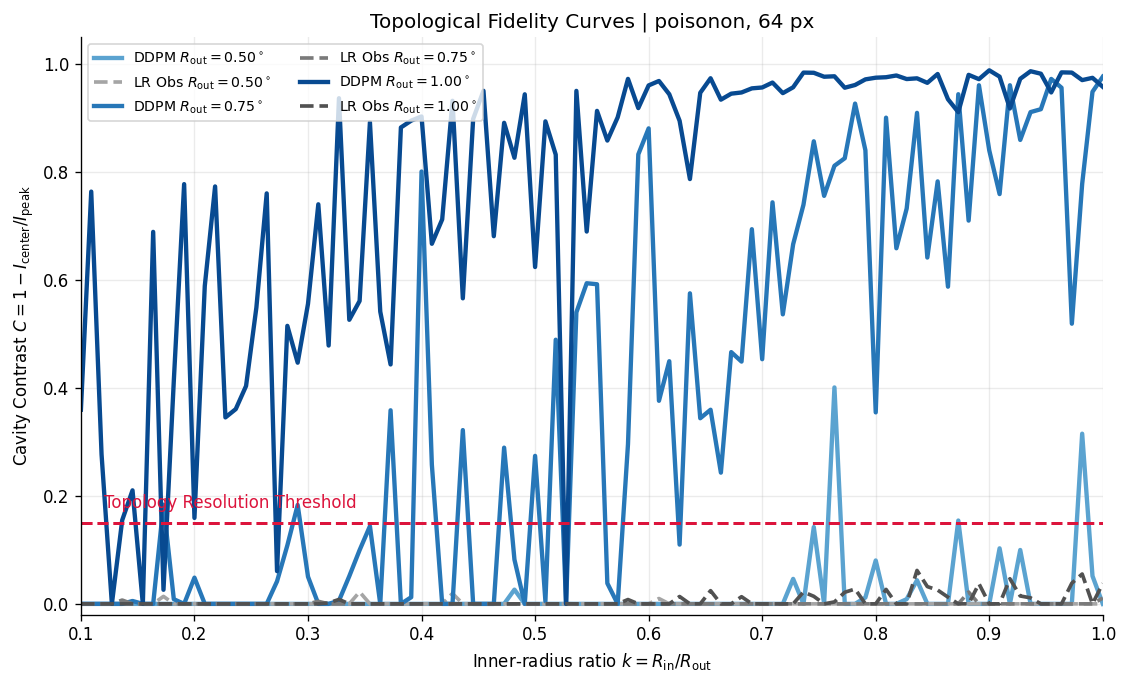

In [8]:
def plot_topological_fidelity_curves():
    ddpm_colors = plt.cm.Blues(np.linspace(0.55, 0.9, len(R_OUTS)))
    lr_colors = plt.cm.Greys(np.linspace(0.45, 0.75, len(R_OUTS)))

    fig, ax = plt.subplots(figsize=(9.5, 5.8))
    for r_idx, r_out in enumerate(R_OUTS):
        ax.plot(K_RATIOS, ddpm_contrast[r_idx], color=ddpm_colors[r_idx], lw=2.6, label=rf"DDPM $R_{{\rm out}}={r_out:.2f}^\circ$")
        ax.plot(K_RATIOS, lr_contrast[r_idx], color=lr_colors[r_idx], lw=2.2, ls="--", label=rf"LR Obs $R_{{\rm out}}={r_out:.2f}^\circ$")

    ax.axhline(CAVITY_THRESHOLD, color="crimson", lw=1.8, ls="--")
    ax.text(K_RATIOS.min() + 0.02, CAVITY_THRESHOLD + 0.02, "Topology Resolution Threshold", color="crimson", fontsize=10, va="bottom")
    ax.set_xlabel(r"Inner-radius ratio $k = R_{\rm in}/R_{\rm out}$")
    ax.set_ylabel(r"Cavity Contrast $C = 1 - I_{\rm center}/I_{\rm peak}$")
    ax.set_title(f"Topological Fidelity Curves | {MAP_KIND}, {IMAGE_SIZE} px")
    ax.set_xlim(float(K_RATIOS.min()), float(K_RATIOS.max()))
    ymax = max(0.25, float(np.nanmax([lr_contrast, ddpm_contrast])) * 1.08)
    ax.set_ylim(-0.02, min(1.05, ymax))
    ax.legend(ncol=2, fontsize=8.5, frameon=True)
    fig.tight_layout()

    if SAVE_OUTPUTS:
        fig_path = OUTPUT_DIR / f"topological_fidelity_curves__{RUN_STEM}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved topological fidelity curves: {fig_path}")
    plt.show()


plot_topological_fidelity_curves()


## 6. Representative 2D/1D visualizer

If `REPRESENTATIVE_INDEX` is an integer from 0 to 299, the notebook displays that manual case. The automatic success case is chosen from cases where LR is a degenerated disk but DDPM recovers a resolved shell. The failure case list reports DDPM-unresolved shell cases and visualizes one representative failure when available.


In [9]:
def topology_label(resolved):
    return "Resolved Shell" if bool(resolved) else "Degenerated Disk"


def case_summary_line(idx):
    params = index_to_params(idx)
    r_idx = params["r_out_idx"]
    k_idx = params["k_idx"]
    return (
        f"index={idx:3d}, R_out={params['r_out_deg']:.2f} deg, k={params['k_ratio']:.3f}, "
        f"LR C={lr_contrast[r_idx, k_idx]:.3f} ({topology_label(lr_resolved[r_idx, k_idx])}), "
        f"DDPM C={ddpm_contrast[r_idx, k_idx]:.3f} ({topology_label(ddpm_resolved[r_idx, k_idx])})"
    )


def print_case_list(title, indices, max_count=FAILURE_CASE_COUNT):
    print(f"\n=== {title}: {len(indices)} cases ===")
    for idx in indices[:max_count]:
        print(case_summary_line(int(idx)))
    if len(indices) > max_count:
        print(f"... {len(indices) - max_count} more cases not printed")


def select_success_case():
    candidates = np.asarray(lr_failed_ddpm_resolved_indices, dtype=int)
    if len(candidates) == 0:
        return None
    gains = ddpm_contrast.ravel()[candidates] - lr_contrast.ravel()[candidates]
    return int(candidates[int(np.argmax(gains))])


def select_failure_case():
    candidates = np.asarray(ddpm_failed_indices, dtype=int)
    if len(candidates) == 0:
        return None
    scores = []
    for idx in candidates:
        params = index_to_params(int(idx))
        r_idx = params["r_out_idx"]
        k_idx = params["k_idx"]
        score = (params["k_ratio"], params["r_out_deg"], -ddpm_contrast[r_idx, k_idx])
        scores.append((score, int(idx)))
    return sorted(scores, reverse=True)[0][1]


def plot_topology_case(idx, tag="case"):
    if idx is None:
        return
    idx = int(idx)
    if idx < 0 or idx >= EXPECTED_N_IMAGES:
        raise IndexError(f"REPRESENTATIVE_INDEX must be in [0, {EXPECTED_N_IMAGES - 1}], got {idx}")

    params = index_to_params(idx)
    gt_result = calculate_cavity_contrast(gt_model_np[idx])
    lr_result = calculate_cavity_contrast(lr_model_np[idx])
    ddpm_result = calculate_cavity_contrast(ddpm_np[idx])
    images = [gt_result["metric_image"], lr_result["metric_image"], ddpm_result["metric_image"]]
    titles = ["Ground Truth", "LHAASO Obs", "DDPM Output"]
    results = [gt_result, lr_result, ddpm_result]
    profile_styles = [("black", "-", "GT"), ("crimson", "--", "LR"), ("dodgerblue", "-", "DDPM")]

    fig = plt.figure(figsize=(12.5, 7.0))
    gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 0.85])
    axes_img = [fig.add_subplot(gs[0, col]) for col in range(3)]
    ax_profile = fig.add_subplot(gs[1, :])

    for ax, image, title, result in zip(axes_img, images, titles, results):
        im = ax.imshow(image, origin="lower", cmap="inferno", vmin=0.0, vmax=1.0, interpolation="nearest")
        ax.scatter([result["x_cen"]], [result["y_cen"]], c="cyan", marker="+", s=70, linewidths=1.6)
        ax.set_title(f"{title}\nC={result['cavity_contrast']:.3f}, {result['topology']}")
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for result, (color, linestyle, label) in zip(results, profile_styles):
        profile = result["radial_profile"]
        radii = result["radii"]
        peak_idx = int(np.argmax(profile)) if len(profile) else 0
        ax_profile.plot(radii, profile, color=color, ls=linestyle, lw=2.0, label=f"{label}: C={result['cavity_contrast']:.3f}, {result['topology']}")
        if len(profile):
            ax_profile.scatter([0], [result["i_center"]], color=color, marker="o", s=32)
            ax_profile.scatter([peak_idx], [result["i_peak"]], color=color, marker="^", s=42)

    ax_profile.set_xlabel("Radius from photometric centroid [pixels]")
    ax_profile.set_ylabel("Azimuthally averaged normalized intensity")
    ax_profile.set_title("1D radial profiles")
    ax_profile.legend(fontsize=8.5)
    ax_profile.text(0.985, 0.96, f"index={idx}\nR_out={params['r_out_deg']:.2f} deg\nk={params['k_ratio']:.3f}\nthreshold={CAVITY_THRESHOLD:.2f}", transform=ax_profile.transAxes, ha="right", va="top", bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.9}, fontsize=9)

    fig.suptitle(f"Topological shell/disk case: {tag}", y=0.995, fontsize=14)
    fig.tight_layout()
    if SAVE_OUTPUTS:
        fig_path = OUTPUT_DIR / f"topological_limit_{tag}__idx{idx:03d}__{RUN_STEM}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"Saved case figure: {fig_path}")
    plt.show()



=== LR degenerated but DDPM resolved: 156 cases ===
index= 73, R_out=0.50 deg, k=0.764, LR C=0.000 (Degenerated Disk), DDPM C=0.401 (Resolved Shell)
index= 85, R_out=0.50 deg, k=0.873, LR C=0.000 (Degenerated Disk), DDPM C=0.154 (Resolved Shell)
index= 97, R_out=0.50 deg, k=0.982, LR C=0.000 (Degenerated Disk), DDPM C=0.315 (Resolved Shell)
index=108, R_out=0.75 deg, k=0.173, LR C=0.000 (Degenerated Disk), DDPM C=0.184 (Resolved Shell)
index=121, R_out=0.75 deg, k=0.291, LR C=0.000 (Degenerated Disk), DDPM C=0.183 (Resolved Shell)
index=130, R_out=0.75 deg, k=0.373, LR C=0.000 (Degenerated Disk), DDPM C=0.359 (Resolved Shell)
index=133, R_out=0.75 deg, k=0.400, LR C=0.000 (Degenerated Disk), DDPM C=0.801 (Resolved Shell)
index=134, R_out=0.75 deg, k=0.409, LR C=0.000 (Degenerated Disk), DDPM C=0.258 (Resolved Shell)
index=137, R_out=0.75 deg, k=0.436, LR C=0.000 (Degenerated Disk), DDPM C=0.322 (Resolved Shell)
index=141, R_out=0.75 deg, k=0.473, LR C=0.000 (Degenerated Disk), DDPM C=

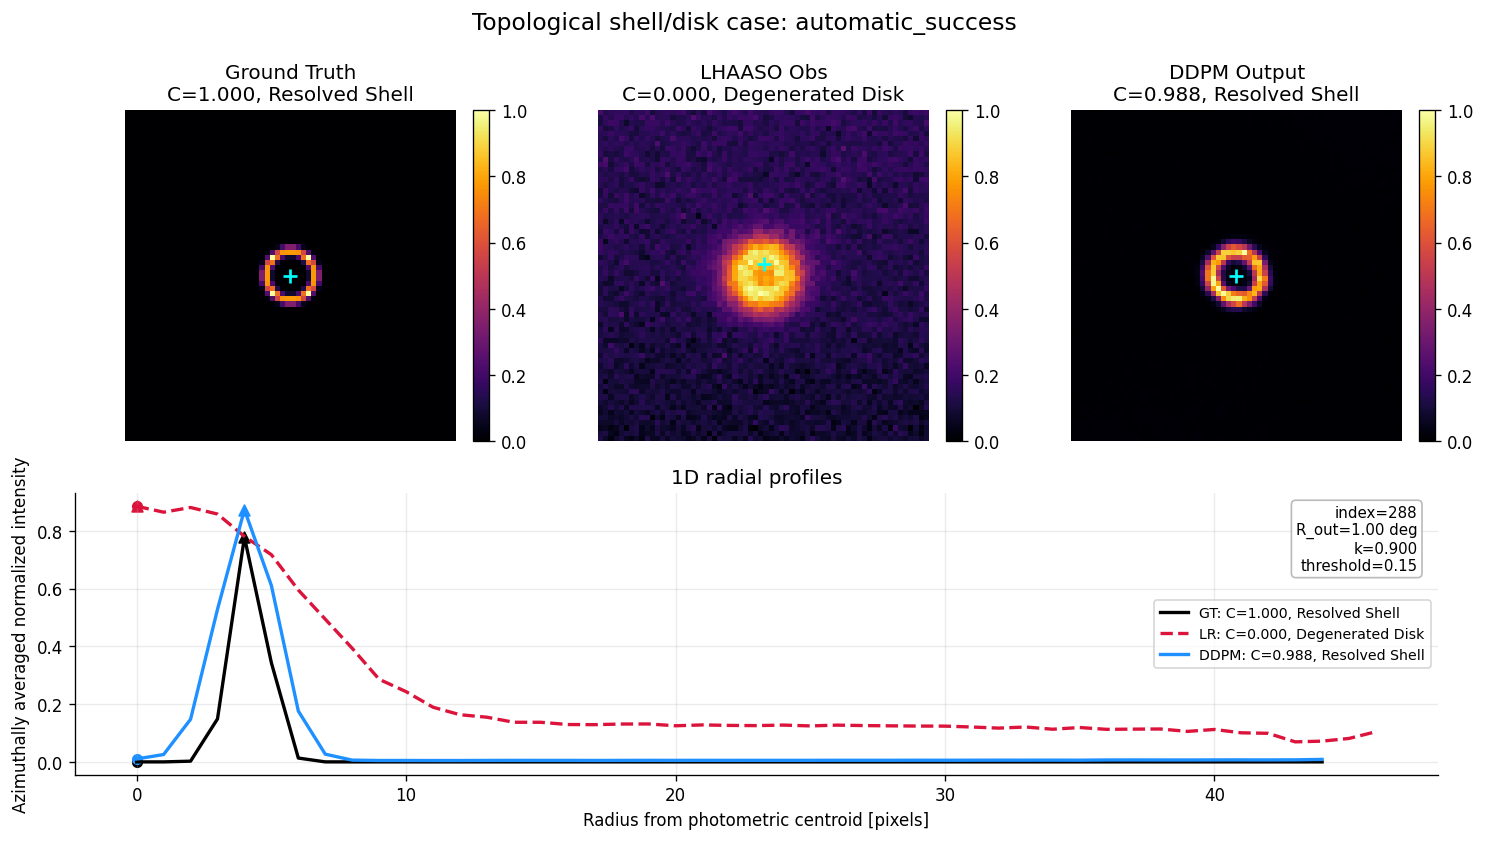


Representative DDPM failure case
index= 99, R_out=0.50 deg, k=1.000, LR C=0.000 (Degenerated Disk), DDPM C=0.000 (Degenerated Disk)
Saved case figure: /root/LHAI_novel/saves/EVAL/DDPM/TopologicalLimit/topological_limit_ddpm_failure__idx099__SDpoisonon_300_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.png


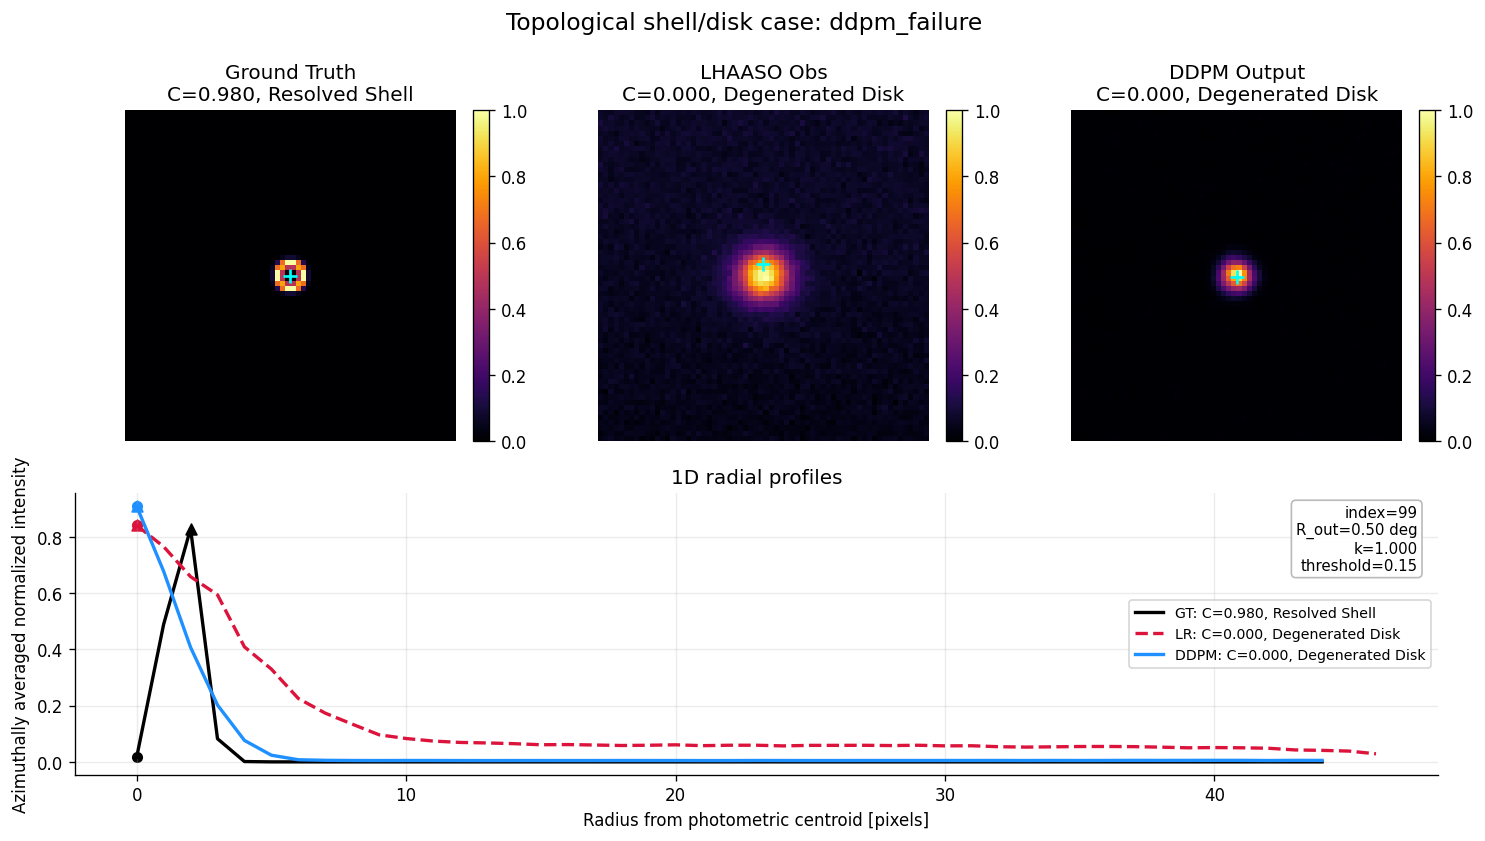

In [10]:
print_case_list("LR degenerated but DDPM resolved", lr_failed_ddpm_resolved_indices)
print_case_list("DDPM unresolved failures", ddpm_failed_indices)
print_case_list("LR resolved but DDPM failed", lr_resolved_ddpm_failed_indices)
print_case_list("Both LR and DDPM failed", both_failed_indices)

if REPRESENTATIVE_INDEX is not None:
    print("\nManual representative case")
    print(case_summary_line(int(REPRESENTATIVE_INDEX)))
    plot_topology_case(int(REPRESENTATIVE_INDEX), tag="manual")
else:
    print("\nREPRESENTATIVE_INDEX is None; skipping manual case visualization.")

if SHOW_AUTOMATIC_SUCCESS_CASE:
    success_idx = select_success_case()
    if success_idx is None:
        print("\nNo automatic success case found where LR failed and DDPM resolved.")
    else:
        print("\nAutomatic success case")
        print(case_summary_line(success_idx))
        plot_topology_case(success_idx, tag="automatic_success")

if SHOW_FAILURE_CASE:
    failure_idx = select_failure_case()
    if failure_idx is None:
        print("\nNo DDPM failure case found; all shells are resolved by the threshold.")
    else:
        print("\nRepresentative DDPM failure case")
        print(case_summary_line(failure_idx))
        plot_topology_case(failure_idx, tag="ddpm_failure")


## 7. Save structured results

The output CSV contains one row per source type and grid point, with the resolved/degenerated topology decision and centroid/contrast diagnostics used to make that decision.


In [11]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    np.save(OUTPUT_DIR / f"gt_cavity_contrast__{RUN_STEM}.npy", gt_contrast.astype(np.float32))
    np.save(OUTPUT_DIR / f"lr_cavity_contrast__{RUN_STEM}.npy", lr_contrast.astype(np.float32))
    np.save(OUTPUT_DIR / f"ddpm_cavity_contrast__{RUN_STEM}.npy", ddpm_contrast.astype(np.float32))
    np.save(OUTPUT_DIR / f"gt_resolved__{RUN_STEM}.npy", gt_resolved.astype(np.float32))
    np.save(OUTPUT_DIR / f"lr_resolved__{RUN_STEM}.npy", lr_resolved.astype(np.float32))
    np.save(OUTPUT_DIR / f"ddpm_resolved__{RUN_STEM}.npy", ddpm_resolved.astype(np.float32))

    csv_path = OUTPUT_DIR / f"topological_limit_results__{RUN_STEM}.csv"
    fieldnames = [
        "source", "index", "r_out_idx", "k_idx", "r_out_deg", "k_ratio",
        "cavity_contrast", "resolved", "topology", "i_center", "i_peak", "y_cen", "x_cen",
    ]
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for source_name in ["GT", "LR", "DDPM"]:
            writer.writerows(evaluation_results[source_name]["rows"])

    metadata = {
        "data_path": str(data_path),
        "model_weight_path": str(model_weight_path),
        "map_kind": MAP_KIND,
        "image_size": IMAGE_SIZE,
        "data_range": DATA_RANGE,
        "metric_minmax_normalize": METRIC_MINMAX_NORMALIZE,
        "cavity_threshold": CAVITY_THRESHOLD,
        "r_outs": R_OUTS.tolist(),
        "k_ratios": K_RATIOS.tolist(),
        "index_logic": "r_out_idx = index // 100; k_idx = index % 100",
        "lr_failed_ddpm_resolved_indices": lr_failed_ddpm_resolved_indices,
        "ddpm_failed_indices": ddpm_failed_indices,
        "both_failed_indices": both_failed_indices,
        "lr_resolved_ddpm_failed_indices": lr_resolved_ddpm_failed_indices,
        "representative_index": REPRESENTATIVE_INDEX,
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    metadata_path = OUTPUT_DIR / f"topological_limit_metadata__{RUN_STEM}.json"
    metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

    print(f"Saved arrays under: {OUTPUT_DIR}")
    print(f"Saved CSV: {csv_path}")
    print(f"Saved metadata: {metadata_path}")
else:
    print("SAVE_OUTPUTS is False; no result files were written.")


Saved arrays under: /root/LHAI_novel/saves/EVAL/DDPM/TopologicalLimit
Saved CSV: /root/LHAI_novel/saves/EVAL/DDPM/TopologicalLimit/topological_limit_results__SDpoisonon_300_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.csv
Saved metadata: /root/LHAI_novel/saves/EVAL/DDPM/TopologicalLimit/topological_limit_metadata__SDpoisonon_300_64_test__Last_DDPM_EXP01_400epo_32bth_64size_SR4poisonon.json
